In [ ]:
import numpy as np
from SpaceBalls.postproc_EEI_estimation import estimate_EEI_avg_sh
from SpaceBalls.sph_meshing import get_sphere_grid, get_reshaped_grid, get_spherical_grid_cell_areas
from SpaceBalls.plotter import Plotter
import config.constants as constants
%matplotlib inline

Re = constants.earth_radius()
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
full_lon_vec, full_lat_vec, _ = get_reshaped_grid(lon_vec, lat_vec)
areas = get_spherical_grid_cell_areas(lat_edges_vec, lon_edges_vec, R=Re+800)

lmax_vec = [80] #, 10, 30, 60]
jd_window = [2458119.5, 2458119.5+366]

for lmax in lmax_vec:

    sh = estimate_EEI_avg_sh('case_5_years', sc_names=['sc_C1', 'sc_C2', 'sc_C3'], lmax=lmax,
                        altitude=800, jd_windows=np.array([jd_window]), frame='SFF')
    c_00 = sh.coeffs[0, 0, 0]
    print(f"estimated C00: {c_00:.4f} W/m^2")
    avg_toa = c_00 * (Re + 800)**2 / Re**2

    expanded_sh = sh.expand(lon=full_lon_vec, lat=full_lat_vec)
    expanded_sh = np.reshape(expanded_sh, (n_lat, n_lon))
    #true_avg = np.sum(expanded_sh * areas) / np.sum(areas)
    #print(f"True avg: {true_avg}")

    Plotter.plot_geo_data(expanded_sh, lon_edges_vec, lat_edges_vec, 
                        title=f"Estimated 2018 Average (D/O {lmax}): {avg_toa:.4f} W/m$^2$", data_label='Net radial flux (W/m$^2$)')


jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are exactly equal - stacking individual sc arrays
jd_vecs are ex

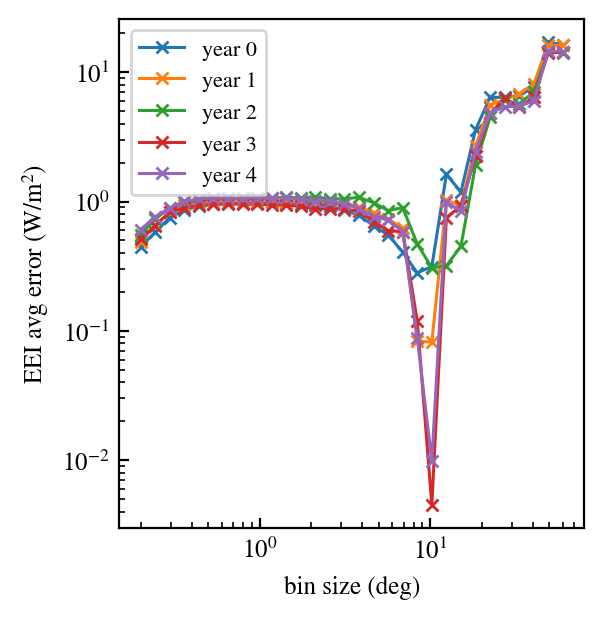

In [3]:
from SpaceBalls.utils import normal_smoother
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg_sh, estimate_EEI_avg
from SpaceBalls.plotter import Plotter
import numpy as np


# Load truth
EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)
EEI_smooth_true = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=365, 
                                      out_length_mode='same_with_nans')

yearly_day_shift = np.arange(0, 365*5, 365)
all_avg_errors = [None] * len(yearly_day_shift)

for j, shift in enumerate(yearly_day_shift):
    jd_window = [2458119.5+shift, 2458119.5+shift+366]
    true_avg_year_1 = np.interp(np.mean(jd_window), full_jd_array, EEI_smooth_true)

    # grid mode
    degree_bin_sizes = np.logspace(np.log10(0.2), np.log10(60), num=30) #[30, 20, 10, 5, 2.5, 1, 0.5, 0.25]
    EEI_avg_errors_grid = np.zeros(len(degree_bin_sizes))

    for i, size_deg in enumerate(degree_bin_sizes):
        avg_grid = estimate_EEI_avg('case_5_years', sc_names=['sc_C101', 'sc_C201', 'sc_C301'], altitude=800, 
                                    jd_windows=np.array([jd_window]), n_lon=int(360/size_deg), n_lat=int(180/size_deg), 
                                    frame='SFF', fill_method='theta_s_fit_simplified')
        EEI_avg_errors_grid[i] = avg_grid[0] - true_avg_year_1
    
    all_avg_errors[j] = EEI_avg_errors_grid

Plotter.plot_convergence(degree_bin_sizes, 
                         {'year '+str(j): np.abs(avg) for j, avg in enumerate(all_avg_errors)},
                         xlabel='bin size (deg)', 
                         ylabel='EEI avg error (W/m$^2$)', f_height=0.8, f_width=0.78)



In [ ]:
from SpaceBalls.utils import normal_smoother
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg_sh, estimate_EEI_avg
from SpaceBalls.plotter import Plotter
import numpy as np

# Load truth
EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)
EEI_smooth_true = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=365, 
                                      out_length_mode='same_with_nans')

yearly_day_shift = np.arange(0, 365*5, 365)
all_avg_errors = [None] * len(yearly_day_shift)

for j, shift in enumerate(yearly_day_shift):
    jd_window = [2458119.5+shift, 2458119.5+shift+366]
    true_avg_year_1 = np.interp(np.mean(jd_window), full_jd_array, EEI_smooth_true)

    # SH mode
    lmax_array = np.round(np.logspace(np.log10(2), np.log10(4), num=15)) #[10, 20, 30, 40, 50, 60, 70, 80]
    EEI_avg_errors_sh = np.zeros(len(lmax_array))

    for i, lmax in enumerate(lmax_array):

        avg_sh = estimate_EEI_avg_sh('case_5_years', sc_names=['sc_C1', 'sc_C2', 'sc_C3'], lmax=int(lmax),
                                altitude=800, jd_windows=np.array([jd_window]), frame='SFF')
        EEI_avg_errors_sh[i] = avg_sh[0] - true_avg_year_1
    
    all_avg_errors[j] = EEI_avg_errors_sh

Plotter.plot_convergence(lmax_array, 
                         {'year '+str(j): np.abs(avg) for j, avg in enumerate(all_avg_errors)},
                         xlabel='l max ()', 
                         ylabel='EEI avg error (W/m$^2$)', f_height=0.8, f_width=0.78,
                         file_name='EEI_avg_convergence_SH.png')



In [ ]:
# SH mode
lmax_array = np.round(np.logspace(np.log10(2), np.log10(80), num=4)) #[10, 20, 30, 40, 50, 60, 70, 80]
EEI_avg_errors_sh = np.zeros(len(lmax_array))

for i, lmax in enumerate(lmax_array):

    avg_sh = estimate_EEI_avg_sh('case_5_years', sc_names=['sc_C1', 'sc_C2', 'sc_C3'], lmax=int(lmax),
                            altitude=800, jd_windows=np.array([jd_window]), frame='SFF')
    EEI_avg_errors_sh[i] = avg_sh[0] - true_avg_year_1

Plotter.plot_convergence(lmax_array, np.abs(EEI_avg_errors_sh), xlabel='lmax', ylabel='EEI avg error (W/m$^2$)')

EEI_avg_errors_sh